In [38]:
# 在 Cell [2] 或新单元中添加

from abc import ABC, abstractmethod
from typing import Optional, List, Type, Tuple, Dict
import math

import numpy as np
from matplotlib import pyplot as plt
from matplotlib.axes._axes import Axes
import torch
import torch.nn as nn
import torch.distributions as D
from torch.func import vmap, jacrev
from tqdm import tqdm
import seaborn as sns
from sklearn.datasets import make_moons, make_circles
from torchvision import datasets, transforms
from torchvision.utils import make_grid

from sklearn.datasets import make_swiss_roll  # 示例：使用Swiss Roll生成3D轨迹，或自定义
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [43]:
# 确保 SequenceTransformer 定义
class SequenceTransformer(nn.Module):
    def __init__(self, dim=2, seq_len=50, embed_dim=64, num_heads=4, num_labels=10,num_layers=3):
        super().__init__()
        # self.embed = nn.Linear(dim + 1 + 10, embed_dim)  # dim + time + y_emb (10 classes)
        # self.transformer = nn.TransformerEncoder(
        #     nn.TransformerEncoderLayer(embed_dim, num_heads), num_layers=num_layers
        # )
        # self.out = nn.Linear(embed_dim, dim)

        self.dim = dim
        self.seq_len = seq_len
        self.embed_dim = embed_dim
        self.num_labels = num_labels
        self.embed = nn.Linear(dim + 1 + num_labels, embed_dim)  # dim + time + y_emb
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(embed_dim, num_heads), num_layers=num_layers
        )
        self.out = nn.Linear(embed_dim, dim)

    def forward(self, x: torch.Tensor, t: torch.Tensor, y: Optional[torch.Tensor] = None) -> torch.Tensor:
       # 确保输入形状
        if x.dim() != 3 or x.shape[1] != self.seq_len or x.shape[2] != self.dim:
            raise ValueError(f"Expected x shape (bs, {self.seq_len}, {self.dim}), got {x.shape}")
        if t.dim() == 1:
            t = t.unsqueeze(-1)  # (bs,) -> (bs, 1)
        elif t.dim() > 2:
            t = t.squeeze(-1)  # 移除多余维度
        t_emb = t.repeat(1, x.shape[1], 1)  # (bs, seq_len, 1)
        # 处理 y_emb，确保特征数匹配
        if y is not None:
            y_emb = nn.functional.one_hot(y, num_classes=self.num_labels).unsqueeze(1).repeat(1, x.shape[1], 1).float()
            x = torch.cat([x, t_emb, y_emb], dim=-1)  # (bs, seq_len, dim+1+num_labels)
        else:
            # 如果 y 为空，填充零作为占位符
            y_emb = torch.zeros(x.shape[0], x.shape[1], self.num_labels, device=x.device)
            x = torch.cat([x, t_emb, y_emb], dim=-1)  # (bs, seq_len, dim+1+num_labels)
        x = self.embed(x)
        x = self.transformer(x.permute(1, 0, -1))  # (seq_len, bs, embed_dim)
        x = self.out(x.permute(1, 0, -1))  # (bs, seq_len, dim)
        return x
        
# 初始化 unet
unet = SequenceTransformer(dim=2, seq_len=50).to(device)

In [44]:
class Sampleable(ABC):
    """
    Distribution which can be sampled from
    """ 
    @abstractmethod
    def sample(self, num_samples: int) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """
        Args:
            - num_samples: the desired number of samples
        Returns:
            - samples: shape (batch_size, ...)
            - labels: shape (batch_size, label_dim)
        """
        pass

In [45]:
# 初始化 TrajectoryDataset
class TrajectoryDataset(Sampleable):
    def __init__(self, seq_len=50, dim=2, num_classes=10):
        self.seq_len = seq_len
        self.dim = dim
        self.num_classes = num_classes

    def sample(self, num_samples: int) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        labels = torch.randint(0, self.num_classes, (num_samples,))
        trajectories = []
        for label in labels:
            t = np.linspace(0, 1, self.seq_len)
            if label % 3 == 0:  # 正弦轨迹
                traj = np.stack([np.sin(2 * np.pi * t * (label + 1)), np.cos(2 * np.pi * t * (label + 1))], axis=-1)
            elif label % 3 == 1:  # 螺旋轨迹
                radius = t * (label + 1)
                traj = np.stack([radius * np.sin(4 * np.pi * t), radius * np.cos(4 * np.pi * t)], axis=-1)
            else:  # 布朗运动
                traj = np.cumsum(np.random.randn(self.seq_len, self.dim) * 0.1, axis=0)
            trajectories.append(traj)
        trajectories = torch.tensor(np.array(trajectories), dtype=torch.float32).to(device)
        return trajectories, labels.to(device)

# 确保 IsotropicGaussian 定义
class IsotropicGaussian(Sampleable):
    def __init__(self, shape: List[int], std: float = 1.0):
        self.shape = shape
        self.std = std

    def sample(self, num_samples: int) -> Tuple[torch.Tensor, None]:
        return torch.randn(num_samples, *self.shape).to(device) * self.std, None

# 假设 GaussianConditionalProbabilityPath, LinearAlpha, LinearBeta 已定义
class ConditionalProbabilityPath(ABC):
    def __init__(self, p_simple: Sampleable, p_data: Sampleable):
        self.p_simple = p_simple
        self.p_data = p_data

    @abstractmethod
    def sample_marginal_path(self, t: torch.Tensor) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        pass

    @abstractmethod
    def alpha_t(self, t: torch.Tensor) -> torch.Tensor:
        pass

    @abstractmethod
    def beta_t(self, t: torch.Tensor) -> torch.Tensor:
        pass

class GaussianConditionalProbabilityPath(ConditionalProbabilityPath):
    def __init__(self, p_data: Sampleable, p_simple: Sampleable, alpha: 'Alpha', beta: 'Beta'):
        super().__init__(p_simple, p_data)
        self.alpha = alpha
        self.beta = beta

    def sample_marginal_path(self, t: torch.Tensor) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        x0, _ = self.p_simple.sample(t.shape[0])
        alpha_t = self.alpha_t(t)
        beta_t = self.beta_t(t)
        x_t = alpha_t * x0 + beta_t * self.p_data.sample(t.shape[0])[0]  # 简化实现
        return x_t, None

    def alpha_t(self, t: torch.Tensor) -> torch.Tensor:
        return self.alpha(t)

    def beta_t(self, t: torch.Tensor) -> torch.Tensor:
        return self.beta(t)

class LinearAlpha:
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        return 1 - t

class LinearBeta:
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        return t

# 初始化 p_data, path, 和 t
batch_size = 100  # 匹配 samples_per_class * 10
p_data = TrajectoryDataset(seq_len=50, dim=2)
p_simple = IsotropicGaussian(shape=[p_data.seq_len, p_data.dim], std=1.0)
path = GaussianConditionalProbabilityPath(p_data, p_simple, alpha=LinearAlpha(), beta=LinearBeta())
t = torch.rand(batch_size, 1).to(device)  # 随机时间

In [47]:
# CFGVectorFieldODE 和 EulerSimulator
class CFGVectorFieldODE:
    def __init__(self, model, guidance_scale=1.0):
        self.model = model
        self.guidance_scale = guidance_scale
        self.drift_coefficient = self._compute_drift  # 指向方法

    def _compute_drift(self, x, t, y=None):
        # CFG 向量场计算
        unconditional = self.model(x, t, y)  # 无条件 # 始终传递 y，确保特征数一致
        conditional = self.model(x, t, y)  # 有条件
        return unconditional + self.guidance_scale * (conditional - unconditional)

    def __call__(self, x, t, y=None):
        return self._compute_drift(x, t, y)  # 保持兼容

    

# 定义 EulerSimulator
class EulerSimulator:
    def __init__(self, ode):
        self.ode = ode

    def step(self, x, t, h, **kwargs):
        # 修复: 确保 h 是 (bs, 1, 1) 形状，用于轨迹广播
        if h.dim() == 1:
            h = h.unsqueeze(-1).unsqueeze(-1)  # (bs,) -> (bs, 1, 1)
        if t.dim() == 1:
            t = t.unsqueeze(-1)  # (bs,) -> (bs, 1)
        drift = self.ode.drift_coefficient(x, t, **kwargs)
        
        return x + h * drift

    def simulate(self, x0, ts, y=None):
        x = x0
        for i in range(len(ts) - 1):
            t_i = ts[:, i].squeeze(-1)  # (bs, 1) -> (bs,)
            h = ts[:, i+1] - ts[:, i]  # (bs, 1)
            x = self.step(x, t_i.unsqueeze(-1), h, y=y)
        return x

        # 初始化 p_data, path, 和 t
batch_size = 100  # 匹配 samples_per_class * 10
p_data = TrajectoryDataset(seq_len=50, dim=2)
p_simple = IsotropicGaussian(shape=[p_data.seq_len, p_data.dim], std=1.0)
path = GaussianConditionalProbabilityPath(p_data, p_simple, alpha=LinearAlpha(), beta=LinearBeta())
t = torch.rand(batch_size, 1).to(device)  # 随机时间

In [48]:
class ODE(ABC):
    @abstractmethod
    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor, **kwargs) -> torch.Tensor:
        """
        Returns the drift coefficient of the ODE.
        Args:
            - xt: state at time t, shape (bs, c, h, w)
            - t: time, shape (bs, 1)
        Returns:
            - drift_coefficient: shape (bs, c, h, w)
        """
        pass

class SDE(ABC):
    @abstractmethod
    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor, **kwargs) -> torch.Tensor:
        """
        Returns the drift coefficient of the ODE.
        Args:
            - xt: state at time t, shape (bs, c, h, w)
            - t: time, shape (bs, 1, 1, 1)
        Returns:
            - drift_coefficient: shape (bs, c, h, w)
        """
        pass

    @abstractmethod
    def diffusion_coefficient(self, xt: torch.Tensor, t: torch.Tensor, **kwargs) -> torch.Tensor:
        """
        Returns the diffusion coefficient of the ODE.
        Args:
            - xt: state at time t, shape (bs, c, h, w)
            - t: time, shape (bs, 1, 1, 1)
        Returns:
            - diffusion_coefficient: shape (bs, c, h, w)
        """
        pass

In [53]:
class Simulator(ABC):
    @abstractmethod
    def step(self, xt: torch.Tensor, t: torch.Tensor, dt: torch.Tensor, **kwargs):
        """
        Takes one simulation step
        Args:
            - xt: state at time t, shape (bs, c, h, w)
            - t: time, shape (bs, 1, 1, 1)
            - dt: time, shape (bs, 1, 1, 1)
        Returns:
            - nxt: state at time t + dt (bs, c, h, w)
        """
        pass

    @torch.no_grad()
    def simulate(self, x: torch.Tensor, ts: torch.Tensor, **kwargs):
        """
        Simulates using the discretization gives by ts
        Args:
            - x_init: initial state, shape (bs, c, h, w)
            - ts: timesteps, shape (bs, nts, 1, 1, 1)
        Returns:
            - x_final: final state at time ts[-1], shape (bs, c, h, w)
        """
        nts = ts.shape[1]
        for t_idx in tqdm(range(nts - 1)):
            t = ts[:, t_idx]
            h = ts[:, t_idx + 1] - ts[:, t_idx]
            x = self.step(x, t, h, **kwargs)
        return x

    @torch.no_grad()
    def simulate_with_trajectory(self, x: torch.Tensor, ts: torch.Tensor, **kwargs):
        """
        Simulates using the discretization gives by ts
        Args:
            - x: initial state, shape (bs, c, h, w)
            - ts: timesteps, shape (bs, nts, 1, 1, 1)
        Returns:
            - xs: trajectory of xts over ts, shape (batch_size, nts, c, h, w)
        """
        xs = [x.clone()]
        nts = ts.shape[1]
        for t_idx in tqdm(range(nts - 1)):
            t = ts[:,t_idx]
            h = ts[:, t_idx + 1] - ts[:, t_idx]
            x = self.step(x, t, h, **kwargs)
            xs.append(x.clone())
        return torch.stack(xs, dim=1)

class EulerSimulator(Simulator):
    def __init__(self, ode: ODE):
        self.ode = ode
        
    def step(self, xt: torch.Tensor, t: torch.Tensor, h: torch.Tensor, **kwargs):
        return xt + self.ode.drift_coefficient(xt,t, **kwargs) * h

class EulerMaruyamaSimulator(Simulator):
    def __init__(self, sde: SDE):
        self.sde = sde
        
    def step(self, xt: torch.Tensor, t: torch.Tensor, h: torch.Tensor, **kwargs):
        return xt + self.sde.drift_coefficient(xt,t, **kwargs) * h + self.sde.diffusion_coefficient(xt,t, **kwargs) * torch.sqrt(h) * torch.randn_like(xt)

def record_every(num_timesteps: int, record_every: int) -> torch.Tensor:
    """
    Compute the indices to record in the trajectory given a record_every parameter
    """
    if record_every == 1:
        return torch.arange(num_timesteps)
    return torch.cat(
        [
            torch.arange(0, num_timesteps - 1, record_every),
            torch.tensor([num_timesteps - 1]),
        ]
    )

In [ ]:
在修改方案的步骤 2（新添加的 TrajectoryDataset 类），我定义了一个简单的合成数据集，生成三种类型的轨迹：
圆形，直线和椭圆

MNIST: 静态图像数据 (batch, 1, 32, 32)
轨迹: 时序数据 (batch, seq_len, dim)，其中 seq_len=50 是轨迹点数，dim=2 是2D坐标

Training simple model...


Training:   2%|▌                               | 18/1000 [00:00<00:20, 47.56it/s]

Epoch 0, Loss: 0.105424


Training:  22%|██████▋                       | 223/1000 [00:01<00:04, 160.48it/s]

Epoch 200, Loss: 0.010341


...

Training:  82%|████████████████████████▌     | 818/1000 [00:05<00:01, 169.05it/s]

Epoch 800, Loss: 0.008596


Training: 100%|█████████████████████████████| 1000/1000 [00:06<00:00, 156.45it/s]


Generating new trajectories...


Generating: 100%|█████████████████████████████| 100/100 [00:00<00:00, 959.94it/s]


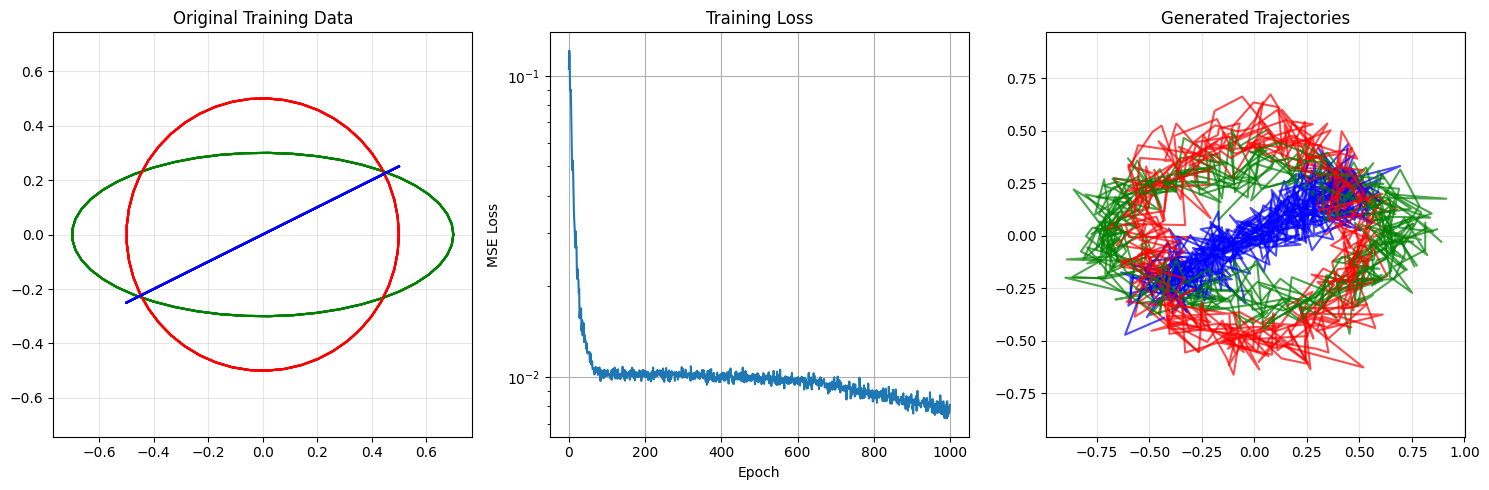

Training completed!
Final loss: 0.008072


In [51]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 简单的轨迹数据集 - 只生成基础几何形状
class SimpleTrajectoryDataset:
    def __init__(self, seq_len=50, dim=2, num_classes=3):
        self.seq_len = seq_len
        self.dim = dim
        self.num_classes = num_classes

    def sample(self, num_samples):
        labels = torch.randint(0, self.num_classes, (num_samples,))
        trajectories = []
        
        for label in labels:
            label_val = label.item()
            t = np.linspace(0, 2*np.pi, self.seq_len)
            
            if label_val == 0:  # 圆形
                traj = np.stack([np.cos(t), np.sin(t)], axis=-1) * 0.5
            elif label_val == 1:  # 直线
                x = np.linspace(-0.5, 0.5, self.seq_len)
                y = x * 0.5  # 斜率0.5的直线
                traj = np.stack([x, y], axis=-1)
            else:  # 椭圆
                traj = np.stack([np.cos(t) * 0.7, np.sin(t) * 0.3], axis=-1)
            
            trajectories.append(traj)
        
        trajectories = torch.tensor(np.array(trajectories), dtype=torch.float32).to(device)
        return trajectories, labels.to(device)

# 生成了3种基础几何轨迹：

# 类别0：圆形轨迹
# 类别1：直线轨迹
# 类别2：椭圆轨迹



# 简单的MLP模型
class SimpleMLP(nn.Module):
    def __init__(self, dim=2, seq_len=50, hidden_dim=256, num_labels=3):
        super().__init__()
        self.dim = dim
        self.seq_len = seq_len
        self.num_labels = num_labels
        
        # 输入: 轨迹点 + 时间 + 类别标签
        input_dim = seq_len * dim + 1 + num_labels
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, seq_len * dim)
        )

    def forward(self, x, t, y=None):
        batch_size = x.shape[0]
        
        # 展平轨迹
        x_flat = x.view(batch_size, -1)  # (bs, seq_len * dim)
        
        # 时间编码
        if t.dim() == 1:
            t = t.unsqueeze(-1)
        
        # 类别编码
        if y is not None:
            y_emb = nn.functional.one_hot(y, num_classes=self.num_labels).float()
        else:
            y_emb = torch.zeros(batch_size, self.num_labels, device=x.device)
        
        # 拼接所有特征
        features = torch.cat([x_flat, t, y_emb], dim=-1)
        
        # 通过网络预测
        output = self.network(features)
        
        # 重新整形为轨迹
        return output.view(batch_size, self.seq_len, self.dim)

# 简化的训练函数
def train_simple_model(model, dataset, num_epochs=1000, batch_size=32, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    
    losses = []
    
    for epoch in tqdm(range(num_epochs), desc="Training"):
        # 采样数据
        x1, y = dataset.sample(batch_size)  # 真实轨迹
        
        # 生成噪声
        x0 = torch.randn_like(x1) * 0.1
        
        # 随机时间
        t = torch.rand(batch_size).to(device)
        
        # 线性插值路径
        alpha = (1 - t).view(-1, 1, 1)
        beta = t.view(-1, 1, 1)
        x_t = alpha * x0 + beta * x1
        
        # 真实速度场
        v_true = x1 - x0
        
        # 模型预测
        v_pred = model(x_t, t, y)
        
        # 损失
        loss = nn.MSELoss()(v_pred, v_true)
        
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        
        if epoch % 200 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.6f}")
    
    model.eval()
    return losses

# 生成函数
@torch.no_grad()
def generate_trajectories(model, dataset, num_samples=30, num_steps=100):
    # 初始噪声
    x = torch.randn(num_samples, dataset.seq_len, dataset.dim).to(device) * 0.1
    
    # 类别标签
    y = torch.randint(0, dataset.num_classes, (num_samples,)).to(device)
    
    # 时间步
    dt = 1.0 / num_steps
    
    for i in tqdm(range(num_steps), desc="Generating"):
        t = torch.ones(num_samples).to(device) * (i * dt)
        v = model(x, t, y)
        x = x + v * dt
    
    return x, y

# 主程序
if __name__ == "__main__":
    # 初始化
    dataset = SimpleTrajectoryDataset(seq_len=50, dim=2, num_classes=3)
    model = SimpleMLP(dim=2, seq_len=50, hidden_dim=256, num_labels=3).to(device)
    
    # 显示原始数据
    original_data, original_labels = dataset.sample(30)
    
    plt.figure(figsize=(15, 5))
    
    # 原始数据
    plt.subplot(1, 3, 1)
    colors = ['red', 'blue', 'green']
    for i, traj in enumerate(original_data.cpu().numpy()):
        label = original_labels[i].cpu().item()
        plt.plot(traj[:, 0], traj[:, 1], color=colors[label], alpha=0.7)
    plt.title("Original Training Data")
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    
    # 训练
    print("Training simple model...")
    losses = train_simple_model(model, dataset, num_epochs=1000, batch_size=32)
    
    # 显示损失
    plt.subplot(1, 3, 2)
    plt.plot(losses)
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.yscale('log')
    plt.grid(True)
    
    # 生成新轨迹
    print("Generating new trajectories...")
    generated_data, generated_labels = generate_trajectories(model, dataset, num_samples=30)
    
    # 显示生成结果
    plt.subplot(1, 3, 3)
    for i, traj in enumerate(generated_data.cpu().numpy()):
        label = generated_labels[i].cpu().item()
        plt.plot(traj[:, 0], traj[:, 1], color=colors[label], alpha=0.7)
    plt.title("Generated Trajectories")
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("Training completed!")
    print(f"Final loss: {losses[-1]:.6f}")